In [1]:
import os

path = r"C:\Users\ak021\masksim_project\data\synthbuster"

for item in os.listdir(path):
    print(item)

synthbuster


In [2]:
import os

path = r"C:\Users\ak021\masksim_project\data\synthbuster\synthbuster output\synthbuster"

for item in os.listdir(path):
    print(item)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\ak021\\masksim_project\\data\\synthbuster\\synthbuster output\\synthbuster'

In [3]:
import os

path = r"C:\Users\ak021\masksim_project\data\synthbuster\synthbuster output"

for item in os.listdir(path):
    full_path = os.path.join(path, item)
    print(repr(item), "| folder:", os.path.isdir(full_path), "| file:", os.path.isfile(full_path))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\ak021\\masksim_project\\data\\synthbuster\\synthbuster output'

In [4]:
import os

print("Current folder:", os.getcwd())
print("\nContents of data:\n")

for root, dirs, files in os.walk("data"):
    level = root.replace("data", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 3:
        dirs[:] = []

Current folder: C:\Users\ak021\masksim_project

Contents of data:

data/
    fake/
    fake_sd14_raw/
    real/
    synthbuster/
        synthbuster/
            dalle2/
            dalle3/
            firefly/
            glide/
            midjourney-v5/
            stable-diffusion-1-3/
            stable-diffusion-1-4/
            stable-diffusion-2/
            stable-diffusion-xl/


In [5]:
import os

sd14_path = r"C:\Users\ak021\masksim_project\data\synthbuster\synthbuster\stable-diffusion-1-4"

files = [
    f for f in os.listdir(sd14_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp", ".tif", ".tiff"))
]

print("Number of images:", len(files))
print("\nFirst 10 files:")
for f in files[:10]:
    print(f)

Number of images: 1000

First 10 files:
r000da54ft.png
r001d260dt.png
r002fc3e2t.png
r00444b95t.png
r005f3e70t.png
r00617aa1t.png
r00679daet.png
r006b0e4bt.png
r006fcc20t.png
r007f5116t.png


In [6]:
from PIL import Image
import os

for f in files[:10]:
    path = os.path.join(sd14_path, f)
    with Image.open(path) as img:
        print(f, "->", img.size, img.mode)

r000da54ft.png -> (512, 512) RGB
r001d260dt.png -> (512, 512) RGB
r002fc3e2t.png -> (512, 512) RGB
r00444b95t.png -> (512, 512) RGB
r005f3e70t.png -> (512, 512) RGB
r00617aa1t.png -> (512, 512) RGB
r00679daet.png -> (512, 512) RGB
r006b0e4bt.png -> (512, 512) RGB
r006fcc20t.png -> (512, 512) RGB
r007f5116t.png -> (512, 512) RGB


In [7]:
import requests

url = "http://images.cocodataset.org/zips/val2017.zip"
out = r"C:\Users\ak021\masksim_project\data\val2017.zip"

with requests.get(url, stream=True) as r:
    r.raise_for_status()
    total = int(r.headers.get("content-length", 0))

    with open(out, "wb") as f:
        downloaded = 0

        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)

                if total:
                    print(
                        f"\r{downloaded / 1024**2:.1f} MB / "
                        f"{total / 1024**2:.1f} MB",
                        end=""
                    )

print("\nDownload complete.")

777.8 MB / 777.8 MB
Download complete.


In [8]:
import zipfile
import os

zip_path = r"C:\Users\ak021\masksim_project\data\val2017.zip"
extract_path = r"C:\Users\ak021\masksim_project\data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")
print(os.listdir(r"C:\Users\ak021\masksim_project\data"))

Extraction complete.
['fake', 'fake_sd14_raw', 'real', 'synthbuster', 'val2017', 'val2017.zip']


In [9]:
from PIL import Image
import os

coco_path = r"C:\Users\ak021\masksim_project\data\val2017"

coco_files = [
    f for f in os.listdir(coco_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
]

print("Number of COCO images:", len(coco_files))
print()

for f in coco_files[:10]:
    path = os.path.join(coco_path, f)
    with Image.open(path) as img:
        print(f, "->", img.size, img.mode)

Number of COCO images: 5000

000000000139.jpg -> (640, 426) RGB
000000000285.jpg -> (586, 640) RGB
000000000632.jpg -> (640, 483) RGB
000000000724.jpg -> (375, 500) RGB
000000000776.jpg -> (428, 640) RGB
000000000785.jpg -> (640, 425) RGB
000000000802.jpg -> (424, 640) RGB
000000000872.jpg -> (621, 640) RGB
000000000885.jpg -> (640, 427) RGB
000000001000.jpg -> (640, 480) RGB


In [10]:
import os
import random
import json

random.seed(42)

# Fake: all 1000 SD 1.4 images
fake_files = [
    os.path.join(sd14_path, f)
    for f in os.listdir(sd14_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))
]

# Real: randomly choose 1000 from COCO
real_files = [
    os.path.join(coco_path, f)
    for f in os.listdir(coco_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))
]

random.shuffle(fake_files)
random.shuffle(real_files)

real_files = real_files[:1000]

splits = {
    "train": {
        "real": real_files[:700],
        "fake": fake_files[:700]
    },
    "val": {
        "real": real_files[700:850],
        "fake": fake_files[700:850]
    },
    "test": {
        "real": real_files[850:1000],
        "fake": fake_files[850:1000]
    }
}

with open("data/splits.json", "w") as f:
    json.dump(splits, f, indent=2)

for split in splits:
    print(
        split,
        "| real:", len(splits[split]["real"]),
        "| fake:", len(splits[split]["fake"])
    )

train | real: 700 | fake: 700
val | real: 150 | fake: 150
test | real: 150 | fake: 150


In [11]:
import requests
from tqdm import tqdm

url = "https://loki.disi.unitn.it/RAISE/getFile.php?p=1k"
out = r"C:\Users\ak021\masksim_project\data\raise_1k.zip"

with requests.get(url, stream=True) as r:
    r.raise_for_status()

    total = int(r.headers.get("content-length", 0))
    chunk_size = 1024 * 1024  # 1 MB

    with open(out, "wb") as f:
        with tqdm(
            total=total,
            unit="B",
            unit_scale=True,
            unit_divisor=1024
        ) as pbar:

            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))

print("Download complete:", out)

48.4kB [00:00, 107kB/s]

Download complete: C:\Users\ak021\masksim_project\data\raise_1k.zip


In [12]:
import os
import zipfile

path = r"C:\Users\ak021\masksim_project\data\raise_1k.zip"

print("File size:", os.path.getsize(path), "bytes")
print("Is valid ZIP:", zipfile.is_zipfile(path))

with open(path, "rb") as f:
    print("First 100 bytes:")
    print(f.read(100))

File size: 49557 bytes
Is valid ZIP: True
First 100 bytes:
b'PK\x03\x04\x14\x00\x02\x00\x08\x00\xf6xuE\xa1\xab\x03\x1a\x1b\xc1\x00\x00\x17\x0f\x08\x00\x0c\x00\x00\x00RAISE_1k.csv\xdc]\xddr\x1b7\x96\xbe\xdf\xaa}\x87._\xc5\x95\x16\x85\xdfn\xa0s%[V\xa2\x1a\xd9\xceX\x1aO\xd5N\xe5\xa2I6-\xceH\xa4\x8a\xa4&\xf1\xbe\xdb\xd6>\xd2\xbe\xc2\x02h\x80j6'


In [13]:
import zipfile

path = r"C:\Users\ak021\masksim_project\data\raise_1k.zip"

with zipfile.ZipFile(path, "r") as z:
    for info in z.infolist():
        print(info.filename, "->", info.file_size, "bytes")

RAISE_1k.csv -> 528151 bytes


In [14]:
import zipfile
import pandas as pd

zip_path = r"C:\Users\ak021\masksim_project\data\raise_1k.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extract("RAISE_1k.csv", r"C:\Users\ak021\masksim_project\data")

csv_path = r"C:\Users\ak021\masksim_project\data\RAISE_1k.csv"

df = pd.read_csv(csv_path)

print("Rows:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Rows: 1000

Columns:
['File', 'NEF', 'TIFF', 'Date Created', 'Date Modified', 'File Size', 'Image Size', 'Date Shot', 'Time Zone and Date', 'Image Quality', 'Artist', 'Copyright', 'Image Comment', 'Device', 'Lens', 'Focal Length', 'Focus Mode', 'AF-Area Mode', 'VR', 'AF Fine Tune', 'Aperture', 'Shutter Speed', 'Exposure Mode', 'Exposure Comp.', 'Exposure Tuning', 'Metering', 'ISO Sensitivity', 'Flash Device', 'Flash Sync Mode', 'Flash Mode', 'White Balance', 'Color Space', 'High ISO NR', 'Long Exposure NR', 'Active D-Lighting', 'Image Authentication', 'Vignette Control', 'Auto Distortion Control', 'Picture Control', 'Base', 'Quick Adjust', 'Sharpening', 'Contrast', 'Brightness', 'Saturation', 'Hue', 'Filter Effects', 'Toning', 'Optimize Image', 'Color Mode', 'Tone Comp.', 'Hue Adjustment', 'Saturation.1', 'Sharpening.1', 'Latitude', 'Longitude', 'Altitude', 'Altitude Reference', 'Heading', 'UTC', 'Map Datum', 'Scene Mode', 'Keywords']

First 5 rows:


,File,NEF,TIFF,Date Created,Date Modified,File Size,Image Size,Date Shot,Time Zone and Date,Image Quality,...,Sharpening.1,Latitude,Longitude,Altitude,Altitude Reference,Heading,UTC,Map Datum,Scene Mode,Keywords
0,r000da54ft,http://193.205.194.113/RAISE/NEF/r000da54ft.NEF,http://193.205.194.113/RAISE/TIFF/r000da54ft.TIF,9/20/2014 23:51,3/19/2012 9:14,9.79 MB,L (4288 x 2848),14:14.0,"UTC+1, DST:ON",Compressed RAW (12-bit),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nature; outdoor
1,r001d260dt,http://193.205.194.113/RAISE/NEF/r001d260dt.NEF,http://193.205.194.113/RAISE/TIFF/r001d260dt.TIF,9/21/2014 9:58,5/11/2013 6:45,20.0 MB,L (4928 x 3264),45:58.6,"UTC+1, DST:ON",Lossless Compressed RAW (14-bit),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aperture Priority,buildings; outdoor
2,r002fc3e2t,http://193.205.194.113/RAISE/NEF/r002fc3e2t.NEF,http://193.205.194.113/RAISE/TIFF/r002fc3e2t.TIF,9/21/2014 3:29,5/4/2014 8:42,21.5 MB,L (4928 x 3264),42:11.6,"UTC+1, DST:ON",Lossless Compressed RAW (14-bit),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,outdoor; people
3,r00444b95t,http://193.205.194.113/RAISE/NEF/r00444b95t.NEF,http://193.205.194.113/RAISE/TIFF/r00444b95t.TIF,9/21/2014 12:20,9/2/2013 11:02,19.8 MB,L (4928 x 3264),02:23.5,"UTC+1, DST:ON",Lossless Compressed RAW (14-bit),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manual,buildings; outdoor
4,r005f3e70t,http://193.205.194.113/RAISE/NEF/r005f3e70t.NEF,http://193.205.194.113/RAISE/TIFF/r005f3e70t.TIF,9/20/2014 23:19,2/18/2012 12:08,10.6 MB,L (4288 x 2848),08:05.0,"UTC+1, DST:OFF",Compressed RAW (12-bit),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,buildings; outdoor


In [15]:
import requests

url = df.iloc[0]["TIFF"]

print("URL:", url)

r = requests.get(url, stream=True, timeout=30)

print("Status:", r.status_code)
print("Content-Type:", r.headers.get("Content-Type"))

size = int(r.headers.get("Content-Length", 0))

if size:
    print(f"File size: {size / 1024**2:.2f} MB")
else:
    print("File size not provided by server")

r.close()

URL: http://193.205.194.113/RAISE/TIFF/r000da54ft.TIF
Status: 200
Content-Type: image/tiff
File size: 14.17 MB


In [16]:
import requests
import numpy as np

sizes = []

for i in range(20):
    url = df.iloc[i]["TIFF"]

    r = requests.get(url, stream=True, timeout=30)

    size = int(r.headers.get("Content-Length", 0))
    r.close()

    if size > 0:
        sizes.append(size)

    print(i + 1, f"{size / 1024**2:.2f} MB")

avg_mb = np.mean(sizes) / 1024**2

print("\nAverage:", f"{avg_mb:.2f} MB")
print("Estimated size for 1000 images:", f"{avg_mb * 1000 / 1024:.2f} GB")


1 14.17 MB
2 19.62 MB
3 31.29 MB
4 24.34 MB
5 20.24 MB
6 18.52 MB
7 18.95 MB
8 21.32 MB
9 31.33 MB
10 21.19 MB
11 28.15 MB
12 27.44 MB
13 20.11 MB
14 28.08 MB
15 25.30 MB
16 15.53 MB
17 21.50 MB
18 21.25 MB
19 25.65 MB
20 23.55 MB

Average: 22.88 MB
Estimated size for 1000 images: 22.34 GB


In [17]:
import requests
from PIL import Image
from io import BytesIO
import os

url = df.iloc[0]["TIFF"]
file_id = df.iloc[0]["File"]

r = requests.get(url, timeout=60)
r.raise_for_status()

img = Image.open(BytesIO(r.content)).convert("RGB")

print("Original:", img.size)

w, h = img.size
s = min(w, h)

left = (w - s) // 2
top = (h - s) // 2

img = img.crop((left, top, left + s, top + s))
img = img.resize((1024, 1024), Image.Resampling.LANCZOS)

out_dir = r"C:\Users\ak021\masksim_project\data\raise_processed"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, f"{file_id}.png")
img.save(out_path)

print("Processed:", img.size)
print("Saved:", out_path)
print("Stored size:", f"{os.path.getsize(out_path) / 1024**2:.2f} MB")

Original: (4288, 2848)
Processed: (1024, 1024)
Saved: C:\Users\ak021\masksim_project\data\raise_processed\r000da54ft.png
Stored size: 1.33 MB


In [19]:
import requests
from PIL import Image
from io import BytesIO
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

out_dir = r"C:\Users\ak021\masksim_project\data\raise_processed"
os.makedirs(out_dir, exist_ok=True)

def download_process(row):
    file_id = row["File"]
    url = row["TIFF"]

    out_path = os.path.join(out_dir, f"{file_id}.png")

    # Skip images already completed
    if os.path.exists(out_path):
        return file_id, "exists"

    try:
        r = requests.get(url, timeout=120)
        r.raise_for_status()

        img = Image.open(BytesIO(r.content)).convert("RGB")

        w, h = img.size
        s = min(w, h)

        left = (w - s) // 2
        top = (h - s) // 2

        img = img.crop((left, top, left + s, top + s))
        img = img.resize((1024, 1024), Image.Resampling.LANCZOS)

        img.save(out_path)

        return file_id, "done"

    except Exception as e:
        return file_id, str(e)


rows = [row for _, row in df.iterrows()]

failed = []

with ThreadPoolExecutor(max_workers=4) as executor:
    futures = [executor.submit(download_process, row) for row in rows]

    for future in tqdm(as_completed(futures), total=len(futures)):
        file_id, status = future.result()

        if status not in ["done", "exists"]:
            failed.append((file_id, status))

print("Finished")
print("Failed:", len(failed))

100%|██████████| 1000/1000 [55:59<00:00,  3.36s/it] 

Finished
Failed: 13


In [20]:
import os

raise_processed_path = r"C:\Users\ak021\masksim_project\data\raise_processed"

raise_files = [
    f for f in os.listdir(raise_processed_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Processed real images:", len(raise_files))
print("\nFirst 10 files:")
for f in raise_files[:10]:
    print(f)

Processed real images: 987

First 10 files:
r000da54ft.png
r001d260dt.png
r002fc3e2t.png
r00444b95t.png
r005f3e70t.png
r00617aa1t.png
r00679daet.png
r006b0e4bt.png
r006fcc20t.png
r007f5116t.png


In [21]:
import os

real_dir = r"C:\Users\ak021\masksim_project\data\raise_processed"
fake_dir = r"C:\Users\ak021\masksim_project\data\synthbuster\synthbuster\stable-diffusion-1-4"

real_ids = {
    os.path.splitext(f)[0]
    for f in os.listdir(real_dir)
    if f.lower().endswith(".png")
}

fake_ids = {
    os.path.splitext(f)[0]
    for f in os.listdir(fake_dir)
    if f.lower().endswith(".png")
}

paired_ids = sorted(real_ids & fake_ids)

print("Real images:", len(real_ids))
print("Fake images:", len(fake_ids))
print("Matched real/fake pairs:", len(paired_ids))

print("\nFirst 10 matched IDs:")
for x in paired_ids[:10]:
    print(x)

Real images: 987
Fake images: 1000
Matched real/fake pairs: 987

First 10 matched IDs:
r000da54ft
r001d260dt
r002fc3e2t
r00444b95t
r005f3e70t
r00617aa1t
r00679daet
r006b0e4bt
r006fcc20t
r007f5116t


In [22]:
import os
import random
import json

random.seed(42)

real_dir = r"C:\Users\ak021\masksim_project\data\raise_processed"
fake_dir = r"C:\Users\ak021\masksim_project\data\synthbuster\synthbuster\stable-diffusion-1-4"

ids = paired_ids.copy()
random.shuffle(ids)

train_ids = ids[:691]
val_ids   = ids[691:839]
test_ids  = ids[839:]

splits = {
    "train": {
        "real": [os.path.join(real_dir, f"{x}.png") for x in train_ids],
        "fake": [os.path.join(fake_dir, f"{x}.png") for x in train_ids]
    },
    "val": {
        "real": [os.path.join(real_dir, f"{x}.png") for x in val_ids],
        "fake": [os.path.join(fake_dir, f"{x}.png") for x in val_ids]
    },
    "test": {
        "real": [os.path.join(real_dir, f"{x}.png") for x in test_ids],
        "fake": [os.path.join(fake_dir, f"{x}.png") for x in test_ids]
    }
}

with open(r"C:\Users\ak021\masksim_project\data\splits.json", "w") as f:
    json.dump(splits, f, indent=2)

for split in splits:
    print(
        split,
        "| real:", len(splits[split]["real"]),
        "| fake:", len(splits[split]["fake"])
    )

train | real: 691 | fake: 691
val | real: 148 | fake: 148
test | real: 148 | fake: 148


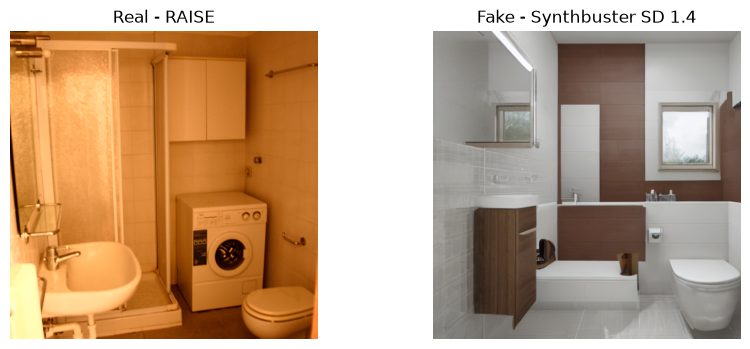

In [23]:
import matplotlib.pyplot as plt
from PIL import Image

sample_id = train_ids[0]

real_path = os.path.join(real_dir, f"{sample_id}.png")
fake_path = os.path.join(fake_dir, f"{sample_id}.png")

real_img = Image.open(real_path)
fake_img = Image.open(fake_path)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(real_img)
plt.title("Real - RAISE")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(fake_img)
plt.title("Fake - Synthbuster SD 1.4")
plt.axis("off")

plt.show()

In [24]:
import io
import json
import random
import torch

from PIL import Image
from torch.utils.data import Dataset


class MaskSimDataset(Dataset):

    def __init__(self, split="train", split_file="data/splits.json"):
        with open(split_file, "r") as f:
            splits = json.load(f)

        self.train = split == "train"

        self.items = []

        for path in splits[split]["real"]:
            self.items.append((path, 0.0))

        for path in splits[split]["fake"]:
            self.items.append((path, 1.0))

        if self.train:
            random.shuffle(self.items)


    def __len__(self):
        return len(self.items)


    def __getitem__(self, idx):

        path, label = self.items[idx]

        img = Image.open(path).convert("RGB")

        # -------------------------
        # 512 x 512 crop
        # -------------------------

        w, h = img.size

        if w > 512 or h > 512:

            if self.train:

                left = random.randint(0, w - 512)
                top  = random.randint(0, h - 512)

            else:

                left = (w - 512) // 2
                top  = (h - 512) // 2

            img = img.crop(
                (left, top, left + 512, top + 512)
            )


        # -------------------------
        # JPEG augmentation
        # paper: quality 65–100
        # applied to BOTH classes
        # -------------------------

        if self.train:

            quality = random.randint(65, 100)

            buffer = io.BytesIO()

            img.save(
                buffer,
                format="JPEG",
                quality=quality
            )

            buffer.seek(0)

            img = Image.open(buffer).convert("RGB")


        # -------------------------
        # PIL -> PyTorch tensor
        # [0,255] -> [0,1]
        # -------------------------

        import numpy as np

        img = np.asarray(img, dtype=np.float32) / 255.0

        img = torch.from_numpy(img).permute(2, 0, 1)

        label = torch.tensor(label, dtype=torch.float32)

        return img, label


print("MaskSimDataset created successfully.")

MaskSimDataset created successfully.


In [25]:
from torch.utils.data import DataLoader

train_dataset = MaskSimDataset("train")
val_dataset = MaskSimDataset("val")
test_dataset = MaskSimDataset("test")

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

img, label = train_dataset[0]

print("\nSingle image shape:", img.shape)
print("Label:", label.item())
print("Pixel range:", img.min().item(), "to", img.max().item())

Train samples: 1382
Val samples: 296
Test samples: 296

Single image shape: torch.Size([3, 512, 512])
Label: 1.0
Pixel range: 0.0 to 1.0


In [26]:
from torch.utils.data import DataLoader
import torch

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

device = torch.device("cuda")

images, labels = next(iter(train_loader))

print("Batch images:", images.shape)
print("Batch labels:", labels.shape)

images = images.to(device)
labels = labels.to(device)

print("Images device:", images.device)
print("Labels device:", labels.device)

print(
    "GPU memory used:",
    round(torch.cuda.memory_allocated() / 1024**2, 2),
    "MB"
)

Batch images: torch.Size([8, 3, 512, 512])
Batch labels: torch.Size([8])
Images device: cuda:0
Labels device: cuda:0
GPU memory used: 24.0 MB


In [27]:
import os
import requests

url = "https://github.com/cszn/KAIR/releases/download/v1.0/dncnn_color_blind.pth"

model_dir = r"C:\Users\ak021\masksim_project\pretrained"
os.makedirs(model_dir, exist_ok=True)

out_path = os.path.join(model_dir, "dncnn_color_blind.pth")

r = requests.get(url, allow_redirects=True)
r.raise_for_status()

with open(out_path, "wb") as f:
    f.write(r.content)

print("Saved to:", out_path)
print("Size:", round(os.path.getsize(out_path) / 1024**2, 2), "MB")

Saved to: C:\Users\ak021\masksim_project\pretrained\dncnn_color_blind.pth
Size: 2.55 MB


In [28]:
import torch

dncnn_path = r"C:\Users\ak021\masksim_project\pretrained\dncnn_color_blind.pth"

state_dict = torch.load(
    dncnn_path,
    map_location="cpu",
    weights_only=True
)

print("Checkpoint type:", type(state_dict))
print("Number of parameter tensors:", len(state_dict))

print("\nFirst 10 parameters:")
for i, (name, tensor) in enumerate(state_dict.items()):
    print(name, tensor.shape)
    if i == 9:
        break

Checkpoint type: <class 'collections.OrderedDict'>
Number of parameter tensors: 40

First 10 parameters:
model.0.weight torch.Size([64, 3, 3, 3])
model.0.bias torch.Size([64])
model.2.weight torch.Size([64, 64, 3, 3])
model.2.bias torch.Size([64])
model.4.weight torch.Size([64, 64, 3, 3])
model.4.bias torch.Size([64])
model.6.weight torch.Size([64, 64, 3, 3])
model.6.bias torch.Size([64])
model.8.weight torch.Size([64, 64, 3, 3])
model.8.bias torch.Size([64])


In [29]:
import torch
import torch.nn as nn


class DnCNN(nn.Module):
    def __init__(self):
        super().__init__()

        layers = []

        # Layer 1: RGB -> 64
        layers.append(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=True)
        )
        layers.append(nn.ReLU(inplace=True))

        # Layers 2-19: 64 -> 64
        for _ in range(18):
            layers.append(
                nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=True)
            )
            layers.append(nn.ReLU(inplace=True))

        # Layer 20: 64 -> RGB
        layers.append(
            nn.Conv2d(64, 3, kernel_size=3, padding=1, bias=True)
        )

        self.model = nn.Sequential(*layers)


    def residual(self, x):
        # Predicted noise/residual
        return self.model(x)


    def forward(self, x):
        # Denoised image
        noise = self.model(x)
        return x - noise


dncnn = DnCNN()

state_dict = torch.load(
    dncnn_path,
    map_location="cpu",
    weights_only=True
)

dncnn.load_state_dict(state_dict, strict=True)

print("DnCNN weights loaded successfully.")

params = sum(p.numel() for p in dncnn.parameters())

print("Parameters:", params)
print("Conv layers:",
      sum(isinstance(m, nn.Conv2d) for m in dncnn.modules()))

DnCNN weights loaded successfully.
Parameters: 668227
Conv layers: 20


In [30]:
dncnn = dncnn.to(device)
dncnn.eval()

images, labels = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    residual = dncnn.residual(images)
    denoised = dncnn(images)

print("Input shape:   ", images.shape)
print("Residual shape:", residual.shape)
print("Denoised shape:", denoised.shape)

print("\nInput range:",
      images.min().item(),
      "to",
      images.max().item())

print("Residual range:",
      residual.min().item(),
      "to",
      residual.max().item())

print("GPU memory used:",
      round(torch.cuda.memory_allocated() / 1024**2, 2),
      "MB")

Input shape:    torch.Size([8, 3, 512, 512])
Residual shape: torch.Size([8, 3, 512, 512])
Denoised shape: torch.Size([8, 3, 512, 512])

Input range: 0.0 to 1.0
Residual range: -0.17845647037029266 to 0.18117289245128632
GPU memory used: 74.55 MB


In [31]:
def rgb_to_ycbcr(x):
    """
    x: tensor [B, 3, H, W], RGB in [0,1]
    returns YCbCr tensor [B, 3, H, W]
    """

    r = x[:, 0:1]
    g = x[:, 1:2]
    b = x[:, 2:3]

    y  = 0.299 * r + 0.587 * g + 0.114 * b

    cb = -0.168736 * r - 0.331264 * g + 0.5 * b + 0.5

    cr = 0.5 * r - 0.418688 * g - 0.081312 * b + 0.5

    return torch.cat([y, cb, cr], dim=1)


images, labels = next(iter(train_loader))
images = images.to(device)

ycbcr = rgb_to_ycbcr(images)

print("RGB shape:  ", images.shape)
print("YCbCr shape:", ycbcr.shape)

print("RGB range:  ",
      images.min().item(),
      "to",
      images.max().item())

print("YCbCr range:",
      ycbcr.min().item(),
      "to",
      ycbcr.max().item())


RGB shape:   torch.Size([8, 3, 512, 512])
YCbCr shape: torch.Size([8, 3, 512, 512])
RGB range:   0.0 to 1.0
YCbCr range: 0.0 to 1.0


In [32]:
def log_mag_spectrum(residual):
    F = torch.fft.fft2(residual, norm="ortho")
    F = torch.fft.fftshift(F, dim=(-2, -1))
    return torch.log(F.abs() + 1e-8)


dncnn.eval()

with torch.no_grad():

    residual = dncnn.residual(ycbcr)

    spectrum = log_mag_spectrum(residual)


print("Residual shape:", residual.shape)
print("Spectrum shape:", spectrum.shape)

print("\nResidual range:",
      residual.min().item(),
      "to",
      residual.max().item())

print("Spectrum range:",
      spectrum.min().item(),
      "to",
      spectrum.max().item())

print("NaN values:",
      torch.isnan(spectrum).any().item())

print("Inf values:",
      torch.isinf(spectrum).any().item())

Residual shape: torch.Size([8, 3, 512, 512])
Spectrum shape: torch.Size([8, 3, 512, 512])

Residual range: -0.6337292194366455 to 0.6026890277862549
Spectrum range: -14.5338773727417 to 0.11085523664951324
NaN values: False
Inf values: False


In [33]:
import torch.nn.functional as F

class MaskSim(nn.Module):
    def __init__(self, h=512, w=512, c=3):
        super().__init__()

        self.conv = nn.Conv2d(c, c, kernel_size=1)

        self.mask_raw = nn.Parameter(
            torch.zeros(c, h, w)
        )

        self.ref = nn.Parameter(
            torch.randn(c, h, w) * 0.01
        )

        self.bn = nn.BatchNorm2d(c)

        self.a = nn.Parameter(torch.zeros(1))
        self.b = nn.Parameter(torch.zeros(1))


    def similarity(self, spec):

        mask = torch.sigmoid(self.mask_raw)

        fm = self.conv(spec)
        fm = fm * mask
        fm = self.bn(fm)

        ref = self.ref - self.ref.mean(
            dim=(-2, -1),
            keepdim=True
        )

        ref = ref.unsqueeze(0)

        num = (fm * ref).flatten(2).sum(-1)

        den = (
            fm.flatten(2).norm(dim=-1)
            *
            ref.flatten(2).norm(dim=-1)
            + 1e-8
        )

        cosine = num / den

        return cosine.mean(dim=1)


    def forward(self, spec):

        sim = self.similarity(spec)

        probability = torch.sigmoid(
            torch.exp(self.a) * sim + self.b
        )

        return probability


masksim = MaskSim(
    h=512,
    w=512,
    c=3
).to(device)

print("MaskSim created.")

print(
    "Trainable parameters:",
    sum(p.numel() for p in masksim.parameters())
)

with torch.no_grad():
    sim = masksim.similarity(spectrum)
    prob = masksim(spectrum)

print("Similarity shape:", sim.shape)
print("Probability shape:", prob.shape)

print("Example similarities:", sim[:5])
print("Example probabilities:", prob[:5])

MaskSim created.
Trainable parameters: 1572884
Similarity shape: torch.Size([8])
Probability shape: torch.Size([8])
Example similarities: tensor([-0.0006, -0.0011, -0.0019,  0.0005, -0.0005], device='cuda:0')
Example probabilities: tensor([0.4999, 0.4997, 0.4995, 0.5001, 0.4999], device='cuda:0')


In [34]:
def masksim_loss(model, spectrum, labels):

    similarity = model.similarity(spectrum)

    # Fake (1): normal cosine similarity
    # Real (0): absolute cosine similarity
    train_similarity = (
        similarity * labels
        +
        similarity.abs() * (1.0 - labels)
    )

    probability = torch.sigmoid(
        torch.exp(model.a) * train_similarity
        + model.b
    )

    loss = F.binary_cross_entropy(
        probability.clamp(1e-6, 1 - 1e-6),
        labels
    )

    return loss


labels = labels.to(device)

loss = masksim_loss(
    masksim,
    spectrum,
    labels
)

print("Initial loss:", loss.item())

Initial loss: 0.693560779094696


In [35]:
optimizer = torch.optim.Adam([
    {
        "params": dncnn.parameters(),
        "lr": 1e-4
    },
    {
        "params": masksim.parameters(),
        "lr": 1e-3
    }
])

scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer,
    gamma=0.99
)

print("Optimizer created successfully.")

print("DnCNN learning rate:",
      optimizer.param_groups[0]["lr"])

print("MaskSim learning rate:",
      optimizer.param_groups[1]["lr"])

print("Total parameters being optimized:",
      sum(
          p.numel()
          for group in optimizer.param_groups
          for p in group["params"]
      ))

Optimizer created successfully.
DnCNN learning rate: 0.0001
MaskSim learning rate: 0.001
Total parameters being optimized: 2241111


In [36]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

dncnn.train()
masksim.train()

images, labels = next(iter(train_loader))

images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

optimizer.zero_grad()

# RGB -> YCbCr
ycbcr = rgb_to_ycbcr(images)

# DnCNN residual
residual = dncnn.residual(ycbcr)

# Frequency spectrum
spectrum = log_mag_spectrum(residual)

# MaskSim loss
loss = masksim_loss(
    masksim,
    spectrum,
    labels
)

# Backpropagation
loss.backward()

print("Loss:", loss.item())

print(
    "DnCNN first-layer grad mean:",
    dncnn.model[0].weight.grad.abs().mean().item()
)

print(
    "Mask grad mean:",
    masksim.mask_raw.grad.abs().mean().item()
)

print(
    "Peak GPU memory:",
    round(torch.cuda.max_memory_allocated() / 1024**3, 2),
    "GB"
)

# Do NOT update weights yet
optimizer.zero_grad()

Loss: 0.6932604908943176
DnCNN first-layer grad mean: 0.0010487142717465758
Mask grad mean: 4.328055638325168e-07
Peak GPU memory: 11.14 GB


In [37]:
import gc
import torch

# Delete large tensors created in earlier cells
for name in [
    "images",
    "labels",
    "ycbcr",
    "residual",
    "spectrum",
    "denoised",
    "sim",
    "prob",
    "loss"
]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

props = torch.cuda.get_device_properties(0)

print("GPU:", props.name)
print(
    "Total VRAM:",
    round(props.total_memory / 1024**3, 2),
    "GB"
)

print(
    "Currently allocated:",
    round(torch.cuda.memory_allocated() / 1024**3, 2),
    "GB"
)

print(
    "Currently reserved:",
    round(torch.cuda.memory_reserved() / 1024**3, 2),
    "GB"
)

GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Total VRAM: 7.96 GB
Currently allocated: 0.01 GB
Currently reserved: 0.5 GB


In [38]:
from torch.utils.data import DataLoader
import gc
import torch

BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

dncnn.train()
masksim.train()

images, labels = next(iter(train_loader))

images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

optimizer.zero_grad()

ycbcr = rgb_to_ycbcr(images)

residual = dncnn.residual(ycbcr)

spectrum = log_mag_spectrum(residual)

loss = masksim_loss(
    masksim,
    spectrum,
    labels
)

loss.backward()

print("Loss:", loss.item())

print(
    "Peak GPU memory:",
    round(torch.cuda.max_memory_allocated() / 1024**3, 2),
    "GB"
)

optimizer.zero_grad()

del images, labels, ycbcr, residual, spectrum, loss
gc.collect()
torch.cuda.empty_cache()

Loss: 0.6936905384063721
Peak GPU memory: 5.57 GB


In [39]:
import time
import gc
from tqdm.auto import tqdm

ACCUMULATION_STEPS = 2

dncnn.train()
masksim.train()

optimizer.zero_grad()

running_loss = 0.0
start_time = time.time()

torch.cuda.reset_peak_memory_stats()

for step, (images, labels) in enumerate(
    tqdm(train_loader, desc="Training epoch 1")
):

    images = images.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)

    # RGB -> YCbCr
    ycbcr = rgb_to_ycbcr(images)

    # DnCNN residual
    residual = dncnn.residual(ycbcr)

    # Frequency spectrum
    spectrum = log_mag_spectrum(residual)

    # MaskSim loss
    loss = masksim_loss(
        masksim,
        spectrum,
        labels
    )

    # Divide because we're accumulating 2 batches
    scaled_loss = loss / ACCUMULATION_STEPS

    scaled_loss.backward()

    # Update every 2 physical batches
    if (
        (step + 1) % ACCUMULATION_STEPS == 0
        or
        (step + 1) == len(train_loader)
    ):
        optimizer.step()
        optimizer.zero_grad()

    running_loss += loss.item()


epoch_loss = running_loss / len(train_loader)

elapsed = time.time() - start_time

print("\nEpoch 1 finished")
print("Average training loss:", epoch_loss)
print(
    "Time:",
    round(elapsed / 60, 2),
    "minutes"
)

print(
    "Peak GPU memory:",
    round(
        torch.cuda.max_memory_allocated() / 1024**3,
        2
    ),
    "GB"
)

gc.collect()
torch.cuda.empty_cache()

C:\Users\ak021\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Training epoch 1: 100%|██████████| 346/346 [06:48<00:00,  1.18s/it]



Epoch 1 finished
Average training loss: 0.6678873656285291
Time: 6.81 minutes
Peak GPU memory: 5.59 GB


In [40]:
from sklearn.metrics import roc_auc_score

dncnn.eval()
masksim.eval()

val_loss_sum = 0.0
val_probs = []
val_labels = []

with torch.no_grad():

    for images, labels in tqdm(
        val_loader,
        desc="Validation"
    ):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        ycbcr = rgb_to_ycbcr(images)

        residual = dncnn.residual(ycbcr)

        spectrum = log_mag_spectrum(residual)

        loss = masksim_loss(
            masksim,
            spectrum,
            labels
        )

        probabilities = masksim(spectrum)

        val_loss_sum += loss.item() * images.size(0)

        val_probs.extend(
            probabilities.cpu().tolist()
        )

        val_labels.extend(
            labels.cpu().tolist()
        )


val_loss = val_loss_sum / len(val_dataset)

val_auc = roc_auc_score(
    val_labels,
    val_probs
)

print("\nValidation results after Epoch 1")
print("Validation loss:", val_loss)
print("Validation AUC:", val_auc)

Validation: 100%|██████████| 37/37 [00:42<00:00,  1.16s/it]



Validation results after Epoch 1
Validation loss: 0.64009037050041
Validation AUC: 0.9341216216216216


In [41]:
import os
import torch

checkpoint_dir = r"C:\Users\ak021\masksim_project\checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Decay learning rates once after completing the epoch
scheduler.step()

checkpoint_path = os.path.join(
    checkpoint_dir,
    "masksim_sd14_epoch1.pt"
)

torch.save({
    "epoch": 1,

    "dncnn_state_dict": dncnn.state_dict(),
    "masksim_state_dict": masksim.state_dict(),

    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),

    "train_loss": epoch_loss,
    "val_loss": val_loss,
    "val_auc": val_auc,

    "physical_batch_size": 4,
    "accumulation_steps": 2,
    "effective_batch_size": 8
}, checkpoint_path)

print("Checkpoint saved:")
print(checkpoint_path)

print("\nValidation AUC:", val_auc)

print(
    "Next DnCNN LR:",
    optimizer.param_groups[0]["lr"]
)

print(
    "Next MaskSim LR:",
    optimizer.param_groups[1]["lr"]
)

Checkpoint saved:
C:\Users\ak021\masksim_project\checkpoints\masksim_sd14_epoch1.pt

Validation AUC: 0.9341216216216216
Next DnCNN LR: 9.900000000000001e-05
Next MaskSim LR: 0.00099


In [42]:
dncnn.eval()
masksim.eval()

val_loss_sum = 0.0
val_probs = []
val_labels = []

with torch.no_grad():

    for images, labels in tqdm(
        val_loader,
        desc="Validation"
    ):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        ycbcr = rgb_to_ycbcr(images)

        residual = dncnn.residual(ycbcr)

        spectrum = log_mag_spectrum(residual)

        # Inference path — no abs() trick
        probabilities = masksim(spectrum)

        loss = F.binary_cross_entropy(
            probabilities.clamp(1e-6, 1 - 1e-6),
            labels
        )

        val_loss_sum += loss.item() * images.size(0)

        val_probs.extend(
            probabilities.cpu().tolist()
        )

        val_labels.extend(
            labels.cpu().tolist()
        )


val_loss = val_loss_sum / len(val_dataset)

val_auc = roc_auc_score(
    val_labels,
    val_probs
)

print("Correct validation loss:", val_loss)
print("Validation AUC:", val_auc)

Validation: 100%|██████████| 37/37 [00:38<00:00,  1.04s/it]

Correct validation loss: 0.6377926001677642
Validation AUC: 0.9341216216216216


In [43]:
import os
import time
import gc
import torch
import torch.nn.functional as F

from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score


TOTAL_EPOCHS = 10
ACCUMULATION_STEPS = 2

checkpoint_dir = r"C:\Users\ak021\masksim_project\checkpoints"

best_path = os.path.join(
    checkpoint_dir,
    "masksim_sd14_best.pt"
)

latest_path = os.path.join(
    checkpoint_dir,
    "masksim_sd14_latest.pt"
)


# Epoch 1 results already obtained
best_val_loss = 0.6377926001677642
best_val_auc = 0.9341216216216216
best_epoch = 1

train_history = [epoch_loss]
val_loss_history = [best_val_loss]
val_auc_history = [best_val_auc]


# Save Epoch 1 as current best before continuing
torch.save({
    "epoch": 1,
    "dncnn_state_dict": dncnn.state_dict(),
    "masksim_state_dict": masksim.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "train_loss": epoch_loss,
    "val_loss": best_val_loss,
    "val_auc": best_val_auc
}, best_path)


for epoch in range(2, TOTAL_EPOCHS + 1):

    print(f"\n{'='*60}")
    print(f"EPOCH {epoch}/{TOTAL_EPOCHS}")
    print(f"{'='*60}")


    # =========================================================
    # TRAIN
    # =========================================================

    dncnn.train()
    masksim.train()

    optimizer.zero_grad()

    running_loss = 0.0
    start_time = time.time()

    for step, (images, labels) in enumerate(
        tqdm(train_loader, desc=f"Train {epoch}")
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        ycbcr = rgb_to_ycbcr(images)

        residual = dncnn.residual(ycbcr)

        spectrum = log_mag_spectrum(residual)

        loss = masksim_loss(
            masksim,
            spectrum,
            labels
        )

        scaled_loss = (
            loss / ACCUMULATION_STEPS
        )

        scaled_loss.backward()


        if (
            (step + 1) % ACCUMULATION_STEPS == 0
            or
            (step + 1) == len(train_loader)
        ):

            optimizer.step()
            optimizer.zero_grad()


        running_loss += loss.item()


    train_loss = (
        running_loss /
        len(train_loader)
    )


    # =========================================================
    # VALIDATION
    # =========================================================

    dncnn.eval()
    masksim.eval()

    val_loss_sum = 0.0

    val_probs = []
    val_labels = []


    with torch.no_grad():

        for images, labels in tqdm(
            val_loader,
            desc=f"Validation {epoch}"
        ):

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            ycbcr = rgb_to_ycbcr(images)

            residual = dncnn.residual(ycbcr)

            spectrum = log_mag_spectrum(
                residual
            )

            # Inference path:
            # NO training-only abs() trick
            probabilities = masksim(
                spectrum
            )

            loss = F.binary_cross_entropy(
                probabilities.clamp(
                    1e-6,
                    1 - 1e-6
                ),
                labels
            )

            val_loss_sum += (
                loss.item()
                * images.size(0)
            )

            val_probs.extend(
                probabilities.cpu().tolist()
            )

            val_labels.extend(
                labels.cpu().tolist()
            )


    current_val_loss = (
        val_loss_sum /
        len(val_dataset)
    )

    current_val_auc = roc_auc_score(
        val_labels,
        val_probs
    )


    # =========================================================
    # LR DECAY
    # =========================================================

    scheduler.step()


    train_history.append(train_loss)

    val_loss_history.append(
        current_val_loss
    )

    val_auc_history.append(
        current_val_auc
    )


    elapsed = (
        time.time()
        - start_time
    ) / 60


    print(
        f"\nEpoch {epoch} results"
    )

    print(
        f"Train loss: {train_loss:.6f}"
    )

    print(
        f"Val loss:   {current_val_loss:.6f}"
    )

    print(
        f"Val AUC:    {current_val_auc:.6f}"
    )

    print(
        f"Time:       {elapsed:.2f} minutes"
    )

    print(
        "DnCNN LR:",
        optimizer.param_groups[0]["lr"]
    )

    print(
        "MaskSim LR:",
        optimizer.param_groups[1]["lr"]
    )


    # =========================================================
    # SAVE LATEST CHECKPOINT
    # =========================================================

    checkpoint = {

        "epoch": epoch,

        "dncnn_state_dict":
            dncnn.state_dict(),

        "masksim_state_dict":
            masksim.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "train_loss":
            train_loss,

        "val_loss":
            current_val_loss,

        "val_auc":
            current_val_auc,

        "train_history":
            train_history,

        "val_loss_history":
            val_loss_history,

        "val_auc_history":
            val_auc_history,

        "physical_batch_size": 4,

        "accumulation_steps": 2,

        "effective_batch_size": 8
    }


    torch.save(
        checkpoint,
        latest_path
    )


    # =========================================================
    # SAVE BEST CHECKPOINT
    # =========================================================

    if current_val_loss < best_val_loss:

        best_val_loss = current_val_loss
        best_val_auc = current_val_auc
        best_epoch = epoch

        torch.save(
            checkpoint,
            best_path
        )

        print(
            ">>> New BEST model saved"
        )


    print(
        f"Best epoch so far: {best_epoch}"
    )

    print(
        f"Best val loss: {best_val_loss:.6f}"
    )

    print(
        f"Best val AUC: {best_val_auc:.6f}"
    )


    gc.collect()
    torch.cuda.empty_cache()


print("\nTRAINING COMPLETE")

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation loss:",
    best_val_loss
)

print(
    "Validation AUC at best-loss epoch:",
    best_val_auc
)

print(
    "\nBest model saved at:"
)

print(best_path)


EPOCH 2/10


Validation 2: 100%|██████████| 37/37 [00:38<00:00,  1.04s/it]



Epoch 2 results
Train loss: 0.615915
Val loss:   0.580943
Val AUC:    0.933665
Time:       6.49 minutes
DnCNN LR: 9.801e-05
MaskSim LR: 0.0009801
>>> New BEST model saved
Best epoch so far: 2
Best val loss: 0.580943
Best val AUC: 0.933665

EPOCH 3/10


Validation 3: 100%|██████████| 37/37 [04:31<00:00,  7.33s/it]



Epoch 3 results
Train loss: 0.582248
Val loss:   0.544915
Val AUC:    0.955853
Time:       10.43 minutes
DnCNN LR: 9.70299e-05
MaskSim LR: 0.000970299
>>> New BEST model saved
Best epoch so far: 3
Best val loss: 0.544915
Best val AUC: 0.955853

EPOCH 4/10


...


Epoch 8 results
Train loss: 0.461072
Val loss:   0.422457
Val AUC:    0.962518
Time:       11.78 minutes
DnCNN LR: 9.227446944279203e-05
MaskSim LR: 0.00092274469442792
>>> New BEST model saved
Best epoch so far: 8
Best val loss: 0.422457
Best val AUC: 0.962518

EPOCH 9/10


Validation 9: 100%|██████████| 37/37 [01:25<00:00,  2.32s/it]



Epoch 9 results
Train loss: 0.450536
Val loss:   0.417429
Val AUC:    0.970964
Time:       7.32 minutes
DnCNN LR: 9.13517247483641e-05
MaskSim LR: 0.0009135172474836408
>>> New BEST model saved
Best epoch so far: 9
Best val loss: 0.417429
Best val AUC: 0.970964

EPOCH 10/10


Validation 10: 100%|██████████| 37/37 [01:36<00:00,  2.61s/it]



Epoch 10 results
Train loss: 0.426695
Val loss:   0.378211
Val AUC:    0.975438
Time:       7.55 minutes
DnCNN LR: 9.043820750088047e-05
MaskSim LR: 0.0009043820750088043
>>> New BEST model saved
Best epoch so far: 10
Best val loss: 0.378211
Best val AUC: 0.975438

TRAINING COMPLETE
Best epoch: 10
Best validation loss: 0.3782106819185051
Validation AUC at best-loss epoch: 0.9754382761139518

Best model saved at:
C:\Users\ak021\masksim_project\checkpoints\masksim_sd14_best.pt


In [44]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

best_path = r"C:\Users\ak021\masksim_project\checkpoints\masksim_sd14_best.pt"

checkpoint = torch.load(
    best_path,
    map_location=device,
    weights_only=False
)

dncnn.load_state_dict(
    checkpoint["dncnn_state_dict"]
)

masksim.load_state_dict(
    checkpoint["masksim_state_dict"]
)

dncnn.eval()
masksim.eval()

test_probs = []
test_labels = []

test_loss_sum = 0.0

with torch.no_grad():

    for images, labels in tqdm(
        test_loader,
        desc="Testing"
    ):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        ycbcr = rgb_to_ycbcr(images)

        residual = dncnn.residual(ycbcr)

        spectrum = log_mag_spectrum(residual)

        probabilities = masksim(spectrum)

        loss = F.binary_cross_entropy(
            probabilities.clamp(1e-6, 1 - 1e-6),
            labels
        )

        test_loss_sum += (
            loss.item() * images.size(0)
        )

        test_probs.extend(
            probabilities.cpu().tolist()
        )

        test_labels.extend(
            labels.cpu().tolist()
        )


test_loss = (
    test_loss_sum / len(test_dataset)
)

test_auc = roc_auc_score(
    test_labels,
    test_probs
)

predictions = [
    1 if p >= 0.5 else 0
    for p in test_probs
]

accuracy = accuracy_score(
    test_labels,
    predictions
)

precision = precision_score(
    test_labels,
    predictions
)

recall = recall_score(
    test_labels,
    predictions
)

f1 = f1_score(
    test_labels,
    predictions
)

cm = confusion_matrix(
    test_labels,
    predictions
)

print("\nFINAL TEST RESULTS")
print("------------------------------")
print("Test loss: ", test_loss)
print("Test AUC:  ", test_auc)
print("Accuracy:  ", accuracy)
print("Precision: ", precision)
print("Recall:    ", recall)
print("F1 score:  ", f1)

print("\nConfusion matrix:")
print(cm)

print("\nBest trained epoch:", checkpoint["epoch"])

Testing: 100%|██████████| 37/37 [00:45<00:00,  1.24s/it]


FINAL TEST RESULTS
------------------------------
Test loss:  0.35991548243406657
Test AUC:   0.9825146092037984
Accuracy:   0.918918918918919
Precision:  0.9025974025974026
Recall:     0.9391891891891891
F1 score:   0.9205298013245033

Confusion matrix:
[[133  15]
 [  9 139]]

Best trained epoch: 10


In [45]:
deployment_path = r"C:\Users\ak021\masksim_project\checkpoints\masksim_sd14_deploy.pt"

torch.save({
    "dncnn_state_dict": checkpoint["dncnn_state_dict"],
    "masksim_state_dict": checkpoint["masksim_state_dict"],

    "model_name": "MaskSim_SD14",
    "generator": "Stable Diffusion 1.4",

    "input_size": 512,
    "threshold": 0.5,

    "test_auc": test_auc,
    "test_accuracy": accuracy,
    "test_f1": f1
}, deployment_path)

print("Deployment model saved:")
print(deployment_path)

print(
    "Size:",
    round(
        os.path.getsize(deployment_path) / 1024**2,
        2
    ),
    "MB"
)

Deployment model saved:
C:\Users\ak021\masksim_project\checkpoints\masksim_sd14_deploy.pt
Size: 8.57 MB
